In [22]:
import ast
import pandas as pd
import numpy as np
import seaborn as sbs
import matplotlib.pyplot as plt
from datasets import load_dataset

datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [23]:
df_Ind = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Engineer')]

In [24]:
df_loc = df_Ind['job_location'].value_counts().head(10).to_frame()
type(df_plot)

pandas.core.frame.DataFrame

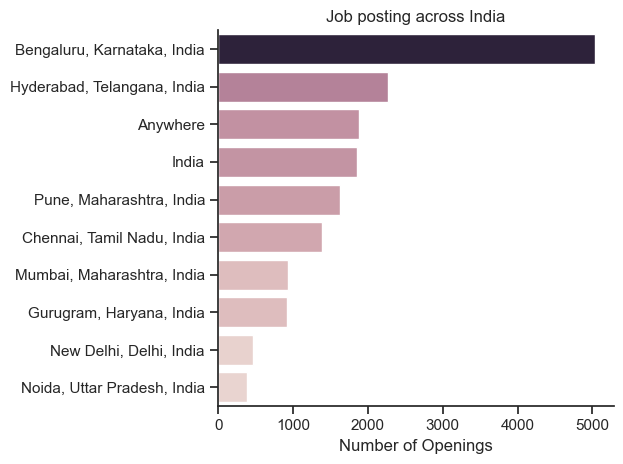

In [25]:
sbs.set_theme(style='ticks')
sbs.barplot(data=df_loc, x='count', y='job_location', hue='count', legend=False)
sbs.despine()
plt.title('Job posting across India')
plt.ylabel('')
plt.xlabel('Number of Openings')
plt.tight_layout()
plt.show()

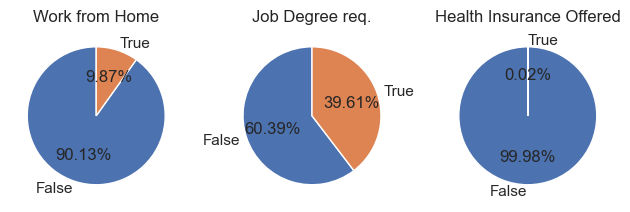

In [26]:
fig, ax = plt.subplots(1,3)

dict_function = {
    'job_work_from_home' : 'Work from Home',
    'job_no_degree_mention' : 'Job Degree req.',
    'job_health_insurance' : 'Health Insurance Offered'
}

for i,(column, title) in enumerate(dict_function.items()):
    ax[i].pie(df_Ind[column].value_counts(), startangle=90, autopct='%1.2f%%', labels=['False', 'True'])
    ax[i].set_title(title)

fig.tight_layout()

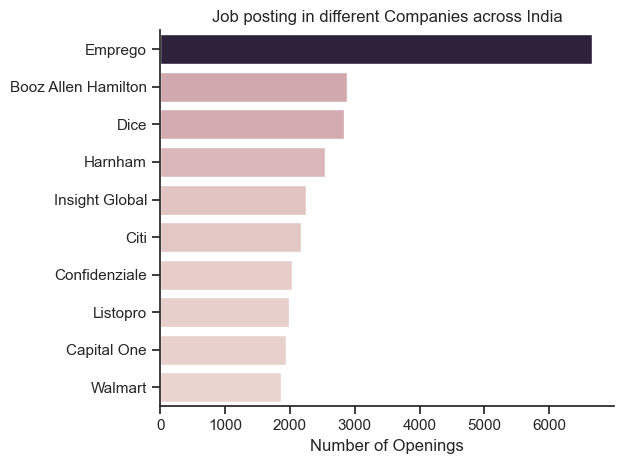

In [27]:
df_com = df['company_name'].value_counts().head(10).to_frame()
sbs.set_theme(style='ticks')
sbs.barplot(data=df_com, x='count', y='company_name', hue='count', legend=False)
sbs.despine()
plt.title('Job posting in different Companies across India')
plt.ylabel('')
plt.xlabel('Number of Openings')
plt.tight_layout()
plt.show()